# 🎯 Task 1 — ML Classification Project
## Telco Customer Churn Prediction
**Alfido Tech Internship | Your Name | Date: June 2026**

---
### What this notebook does:
1. Loads and explores the churn dataset
2. Preprocesses the data (cleaning, encoding, scaling)
3. Trains **2 models**: Logistic Regression & Random Forest
4. Compares both using 5 metrics + cross-validation
5. Plots ROC curves, confusion matrix, feature importance


## Step 1: Import Libraries

In [1]:
# ── All imports ──────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, ConfusionMatrixDisplay,
                             RocCurveDisplay, classification_report)

print("✅ All libraries imported successfully!")


✅ All libraries imported successfully!


## Step 2: Load & Explore the Dataset

In [2]:
# Load the dataset
df = pd.read_csv('churn_data.csv')

print("📊 Dataset Shape:", df.shape)
print("\n📋 First 5 rows:")
df.head()


📊 Dataset Shape: (1000, 17)

📋 First 5 rows:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,TechSupport,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,CUST-0000,Male,0,No,Yes,57,No,Yes,Fiber optic,No,No,Two year,No,Mailed check,39.04,2370.06,No
1,CUST-0001,Female,0,No,Yes,7,Yes,Yes,Fiber optic,No internet service,No,One year,Yes,Credit card,47.03,300.66,Yes
2,CUST-0002,Male,0,No,No,56,Yes,No,Fiber optic,No internet service,No internet service,Month-to-month,No,Electronic check,96.65,5056.11,Yes
3,CUST-0003,Male,0,No,Yes,67,Yes,Yes,No,No,No internet service,One year,No,Mailed check,33.94,2188.08,No
4,CUST-0004,Male,0,Yes,Yes,16,Yes,No,No,Yes,No,Two year,No,Mailed check,22.41,345.70,No


In [3]:
# Check data types and missing values
print("🔍 Data Info:")
print(df.dtypes)
print("\n❓ Missing Values:")
print(df.isnull().sum())


🔍 Data Info:
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
TechSupport             str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
Churn                   str
dtype: object

❓ Missing Values:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
TechSupport         0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


🎯 Churn Distribution:
Churn
No     671
Yes    329
Name: count, dtype: int64

Churn Rate: 32.9%


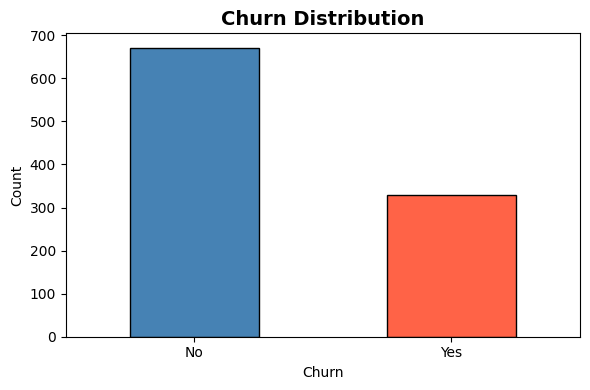

✅ Plot saved!


In [4]:
# Check target variable distribution
print("🎯 Churn Distribution:")
print(df['Churn'].value_counts())
print(f"\nChurn Rate: {(df['Churn']=='Yes').mean()*100:.1f}%")

# Plot churn distribution
plt.figure(figsize=(6,4))
df['Churn'].value_counts().plot(kind='bar', color=['steelblue','tomato'], edgecolor='black')
plt.title('Churn Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Churn')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('plot_churn_distribution.png', dpi=150)
plt.show()
print("✅ Plot saved!")


## Step 3: Data Preprocessing

In [5]:
# ── Preprocessing ────────────────────────────────────

# 1. Drop customerID (not useful for prediction)
df.drop('customerID', axis=1, inplace=True)

# 2. Convert TotalCharges to number (fix any errors)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# 3. Drop rows with missing values
df.dropna(inplace=True)

# 4. Encode all text columns into numbers
le = LabelEncoder()
for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

print("✅ Preprocessing done!")
print("Dataset shape after cleaning:", df.shape)
df.head()


✅ Preprocessing done!
Dataset shape after cleaning: (1000, 16)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,TechSupport,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,1,0,0,1,57,0,2,1,0,0,2,0,3,39.04,2370.06,0
1,0,0,0,1,7,1,2,1,1,0,1,1,1,47.03,300.66,1
2,1,0,0,0,56,1,0,1,1,1,0,0,2,96.65,5056.11,1
3,1,0,0,1,67,1,2,2,0,1,1,0,3,33.94,2188.08,0
4,1,0,1,1,16,1,0,2,2,0,2,0,3,22.41,345.70,0


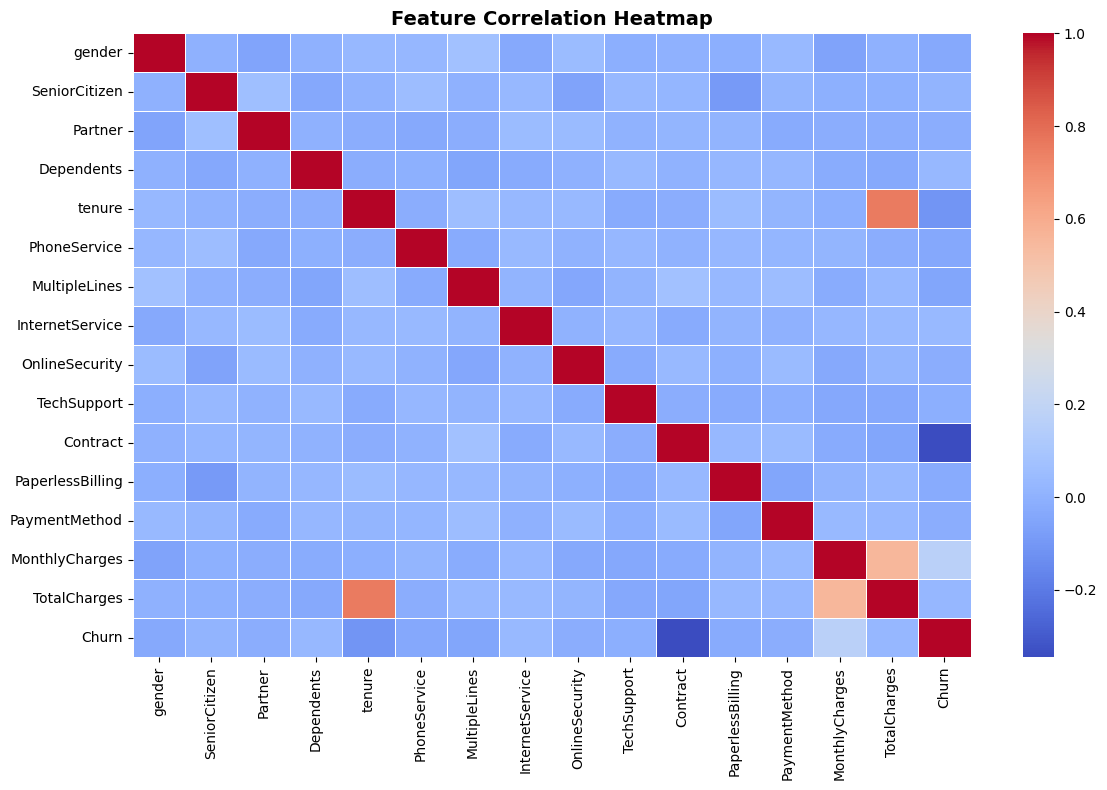

✅ Heatmap saved!


In [6]:
# Correlation heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=False, cmap='coolwarm', linewidths=0.5)
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_correlation_heatmap.png', dpi=150)
plt.show()
print("✅ Heatmap saved!")


## Step 4: Train/Test Split

In [7]:
# Separate features (X) and target (y)
X = df.drop('Churn', axis=1)   # All columns except Churn
y = df['Churn']                  # Only the Churn column

# Split: 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,       # 20% for testing
    random_state=42,     # for reproducibility
    stratify=y           # keep same churn ratio in both sets
)

print(f"✅ Train size: {X_train.shape[0]} rows")
print(f"✅ Test size:  {X_test.shape[0]} rows")
print(f"Train churn rate: {y_train.mean()*100:.1f}%")
print(f"Test  churn rate: {y_test.mean()*100:.1f}%")


✅ Train size: 800 rows
✅ Test size:  200 rows
Train churn rate: 32.9%
Test  churn rate: 33.0%


## Step 5: Feature Scaling (for Logistic Regression)

In [8]:
# StandardScaler brings all features to same scale
# (Important for Logistic Regression, not needed for Random Forest)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)   # fit on train only!
X_test_sc  = scaler.transform(X_test)        # apply same scale to test

print("✅ Scaling done!")
print("Mean of first feature (scaled):", X_train_sc[:, 0].mean().round(4))


✅ Scaling done!
Mean of first feature (scaled): 0.0


## Step 6: Train Both Models

In [9]:
# ── Model 1: Logistic Regression ─────────────────────
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_sc, y_train)
lr_pred = lr_model.predict(X_test_sc)

print("✅ Logistic Regression trained!")

# ── Model 2: Random Forest ────────────────────────────
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

print("✅ Random Forest trained!")


✅ Logistic Regression trained!
✅ Random Forest trained!


## Step 7: Evaluate & Compare Models

In [10]:
# Function to print all 5 required metrics
def evaluate_model(name, y_true, y_pred, model, X_data):
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec  = recall_score(y_true, y_pred)
    f1   = f1_score(y_true, y_pred)
    auc  = roc_auc_score(y_true, model.predict_proba(X_data)[:, 1])
    
    print(f"\n{'='*45}")
    print(f"  Model: {name}")
    print(f"{'='*45}")
    print(f"  Accuracy  : {acc:.4f}  ({acc*100:.1f}%)")
    print(f"  Precision : {prec:.4f}")
    print(f"  Recall    : {rec:.4f}")
    print(f"  F1 Score  : {f1:.4f}")
    print(f"  ROC-AUC   : {auc:.4f}")
    return {'Model': name, 'Accuracy': acc, 'Precision': prec,
            'Recall': rec, 'F1': f1, 'ROC-AUC': auc}

lr_results = evaluate_model("Logistic Regression", y_test, lr_pred, lr_model, X_test_sc)
rf_results = evaluate_model("Random Forest",       y_test, rf_pred, rf_model, X_test)

# Summary table
results_df = pd.DataFrame([lr_results, rf_results]).set_index('Model').round(4)
print("\n\n📊 Summary Table:")
print(results_df.to_string())



  Model: Logistic Regression
  Accuracy  : 0.6550  (65.5%)
  Precision : 0.4795
  Recall    : 0.5303
  F1 Score  : 0.5036
  ROC-AUC   : 0.6923

  Model: Random Forest
  Accuracy  : 0.6600  (66.0%)
  Precision : 0.4792
  Recall    : 0.3485
  F1 Score  : 0.4035
  ROC-AUC   : 0.6802


📊 Summary Table:
                     Accuracy  Precision  Recall      F1  ROC-AUC
Model                                                            
Logistic Regression     0.655     0.4795  0.5303  0.5036   0.6923
Random Forest           0.660     0.4792  0.3485  0.4035   0.6802


## Step 8: Cross-Validation (5-Fold)

In [11]:
# Cross-validation tests the model on 5 different data splits
# This gives a more reliable score than a single test

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

lr_cv_scores = cross_val_score(lr_model, X_train_sc, y_train, cv=cv, scoring='roc_auc')
rf_cv_scores = cross_val_score(rf_model, X_train,    y_train, cv=cv, scoring='roc_auc')

print("📊 5-Fold Cross-Validation ROC-AUC Scores:")
print(f"\nLogistic Regression: {lr_cv_scores.round(4)}")
print(f"  Mean: {lr_cv_scores.mean():.4f} ± {lr_cv_scores.std():.4f}")
print(f"\nRandom Forest: {rf_cv_scores.round(4)}")
print(f"  Mean: {rf_cv_scores.mean():.4f} ± {rf_cv_scores.std():.4f}")


📊 5-Fold Cross-Validation ROC-AUC Scores:

Logistic Regression: [0.7336 0.6845 0.7718 0.7655 0.7443]
  Mean: 0.7399 ± 0.0310

Random Forest: [0.7434 0.6905 0.755  0.7779 0.7223]
  Mean: 0.7378 ± 0.0297


## Step 9: Plots & Visualizations

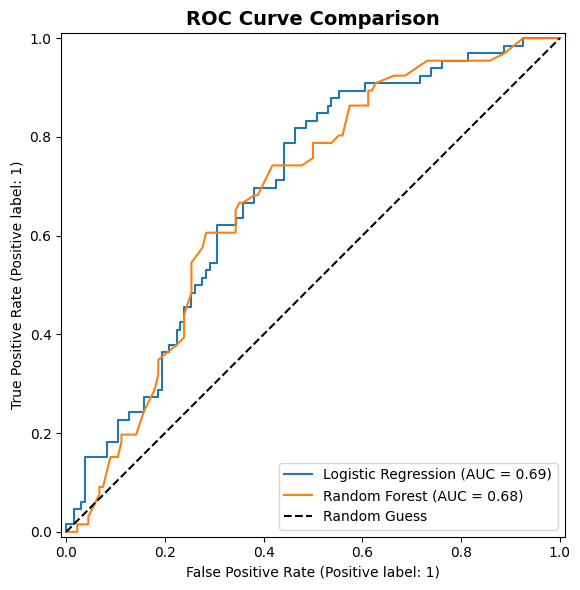

✅ ROC Curve saved!


In [12]:
# ── Plot 1: ROC Curves ───────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))
RocCurveDisplay.from_estimator(lr_model, X_test_sc, y_test, ax=ax, name="Logistic Regression")
RocCurveDisplay.from_estimator(rf_model, X_test,    y_test, ax=ax, name="Random Forest")
ax.plot([0,1],[0,1],'k--', label='Random Guess')
plt.title('ROC Curve Comparison', fontsize=14, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('plot_roc_curves.png', dpi=150)
plt.show()
print("✅ ROC Curve saved!")


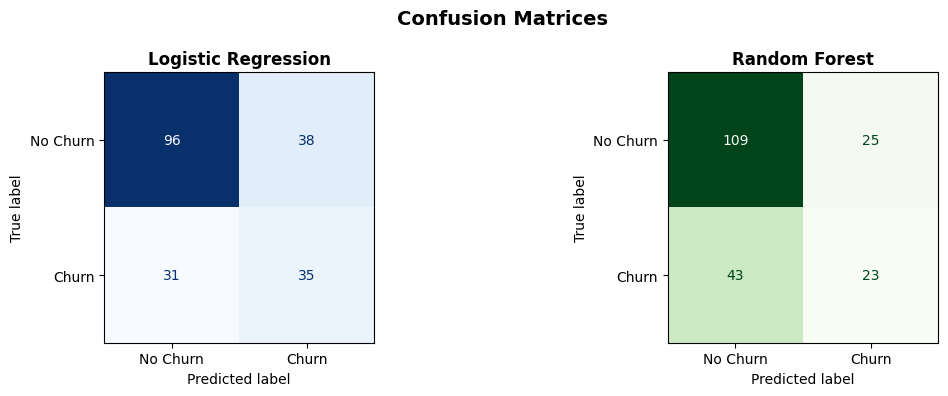

✅ Confusion Matrices saved!


In [13]:
# ── Plot 2: Confusion Matrices ───────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ConfusionMatrixDisplay.from_estimator(
    lr_model, X_test_sc, y_test, ax=axes[0], colorbar=False,
    display_labels=['No Churn', 'Churn'], cmap='Blues'
)
axes[0].set_title('Logistic Regression', fontsize=12, fontweight='bold')

ConfusionMatrixDisplay.from_estimator(
    rf_model, X_test, y_test, ax=axes[1], colorbar=False,
    display_labels=['No Churn', 'Churn'], cmap='Greens'
)
axes[1].set_title('Random Forest', fontsize=12, fontweight='bold')

plt.suptitle('Confusion Matrices', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_confusion_matrices.png', dpi=150)
plt.show()
print("✅ Confusion Matrices saved!")


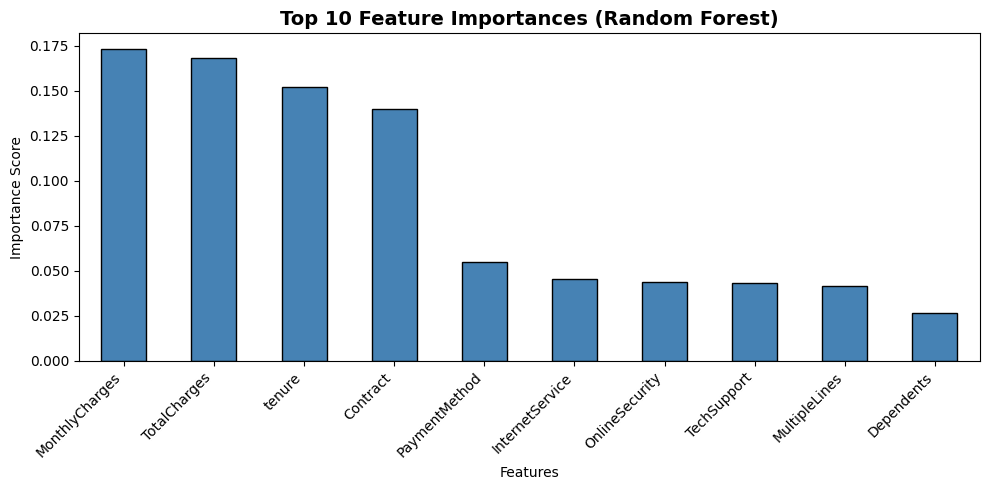

✅ Feature Importance plot saved!


In [14]:
# ── Plot 3: Feature Importance (Random Forest) ───────
importances = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 5))
importances.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Top 10 Feature Importances (Random Forest)', fontsize=14, fontweight='bold')
plt.xlabel('Features')
plt.ylabel('Importance Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('plot_feature_importance.png', dpi=150)
plt.show()
print("✅ Feature Importance plot saved!")


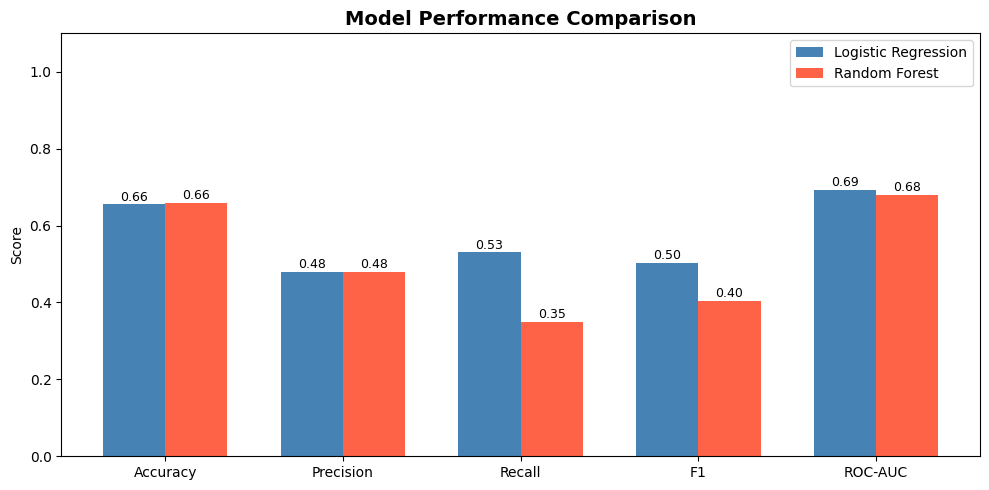

✅ Metrics Comparison plot saved!


In [15]:
# ── Plot 4: Metrics Bar Chart ────────────────────────
metrics = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC']
lr_vals = [lr_results[m] for m in metrics]
rf_vals = [rf_results[m] for m in metrics]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - width/2, lr_vals, width, label='Logistic Regression', color='steelblue')
ax.bar(x + width/2, rf_vals, width, label='Random Forest',       color='tomato')

ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
ax.legend()
for i, (v1, v2) in enumerate(zip(lr_vals, rf_vals)):
    ax.text(i - width/2, v1 + 0.01, f'{v1:.2f}', ha='center', fontsize=9)
    ax.text(i + width/2, v2 + 0.01, f'{v2:.2f}', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('plot_metrics_comparison.png', dpi=150)
plt.show()
print("✅ Metrics Comparison plot saved!")


## Step 10: Conclusion

In [16]:
# Final Summary
print("="*50)
print("  FINAL RESULTS SUMMARY")
print("="*50)
print(results_df.round(4).to_string())
print()

# Which model won?
winner = "Random Forest" if rf_results['ROC-AUC'] > lr_results['ROC-AUC'] else "Logistic Regression"
print(f"\n🏆 Best Model: {winner}")
print(f"   Reason: Higher ROC-AUC score indicates better overall discrimination")
print()
print("📁 Files saved:")
for f in ['plot_churn_distribution.png','plot_correlation_heatmap.png',
          'plot_roc_curves.png','plot_confusion_matrices.png',
          'plot_feature_importance.png','plot_metrics_comparison.png']:
    print(f"   ✅ {f}")


  FINAL RESULTS SUMMARY
                     Accuracy  Precision  Recall      F1  ROC-AUC
Model                                                            
Logistic Regression     0.655     0.4795  0.5303  0.5036   0.6923
Random Forest           0.660     0.4792  0.3485  0.4035   0.6802


🏆 Best Model: Logistic Regression
   Reason: Higher ROC-AUC score indicates better overall discrimination

📁 Files saved:
   ✅ plot_churn_distribution.png
   ✅ plot_correlation_heatmap.png
   ✅ plot_roc_curves.png
   ✅ plot_confusion_matrices.png
   ✅ plot_feature_importance.png
   ✅ plot_metrics_comparison.png
